In [ ]:
# Mount Google Drive
import os
from google.colab import drive
drive.mount('/content/drive')

# Change this to the actual path of your folder on Drive
folder_path = "/content/drive/MyDrive/Personal Project/project/"
os.chdir(folder_path)
print("Current directory:", os.getcwd())
print("Files:", os.listdir())

Mounted at /content/drive
Current directory: /content/drive/MyDrive/Personal Project/project
Files: ['GDSC_DATASET.csv', 'model_list_latest.csv', 'genomic_features.csv', 'Model.csv', 'Main_Preprocessing_1.py', 'Model_Linear Regression and Extra Trees.ipynb', 'Model_Linear Regression and Extra Trees_2.ipynb']


In [ ]:
%run Main_Preprocessing_1.py

/content/drive/MyDrive/Personal Project/project/Main_Preprocessing_1.py:9: DtypeWarning: Columns (7,8) have mixed types. Specify dtype option on import or set low_memory=False.
  df2 = pd.read_csv("genomic_features.csv")


Data loaded:
  df shape : (242035, 19)
  df2 shape: (698000, 9)
  df3 shape: (2266, 96)
  df4 shape: (2132, 49)

After MSI and Growth fill:
  MSI missing         : 630
  Growth Prop missing : 0

After tissue descriptor fills:
  GDSC Tissue descriptor 1 missing: 0
  GDSC Tissue descriptor 2 missing: 0

After feature column cleaning — missing counts:
TARGET                                     27872
DRUG_NAME                                      0
TCGA_DESC                                   1067
Microsatellite instability Status (MSI)      630
Growth Properties                              0
GDSC Tissue descriptor 1                       0
GDSC Tissue descriptor 2                       0

TCGA Stage 1 fill results:
  Missing before                             : 1067
  Filled from cancer-type column             : 360
  Filled manually                            : 707
  Filled from Tissue descriptor 2 (unique)  : 0
  Missing after                              : 0

TCGA Stage 2 (OTHER -> PRA

In [ ]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.model_selection import GridSearchCV, cross_val_score, KFold
from sklearn.metrics import make_scorer, r2_score, mean_absolute_error, mean_squared_error

In [ ]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Linear Regression
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

r2_lr = r2_score(y_test, y_pred_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))

print("Linear Regression")
print(f"R²:  {r2_lr:.4f}")
print(f"MAE: {mae_lr:.4f}")
print(f"RMSE:{rmse_lr:.4f}\n")


Linear Regression
R²:  0.7631
MAE: 1.0079
RMSE:1.3443



In [ ]:
# Extra Trees
etr = ExtraTreesRegressor(n_estimators=100, random_state=42, n_jobs=-1)
etr.fit(X_train_scaled, y_train)
y_pred_etr = etr.predict(X_test_scaled)

r2_etr = r2_score(y_test, y_pred_etr)
mae_etr = mean_absolute_error(y_test, y_pred_etr)
rmse_etr = np.sqrt(mean_squared_error(y_test, y_pred_etr))

print("Extra Trees Regressor")
print(f"R²:  {r2_etr:.4f}")
print(f"MAE: {mae_etr:.4f}")
print(f"RMSE:{rmse_etr:.4f}")

Extra Trees Regressor
R²:  0.7954
MAE: 0.9181
RMSE:1.2494


In [ ]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Extra Trees"],
    "R²": [r2_lr, r2_etr],
    "MAE": [mae_lr, mae_etr],
    "RMSE": [rmse_lr, rmse_etr]
})
print(comparison.round(4))

               Model      R²     MAE    RMSE
0  Linear Regression  0.7631  1.0079  1.3443
1        Extra Trees  0.7954  0.9181  1.2494


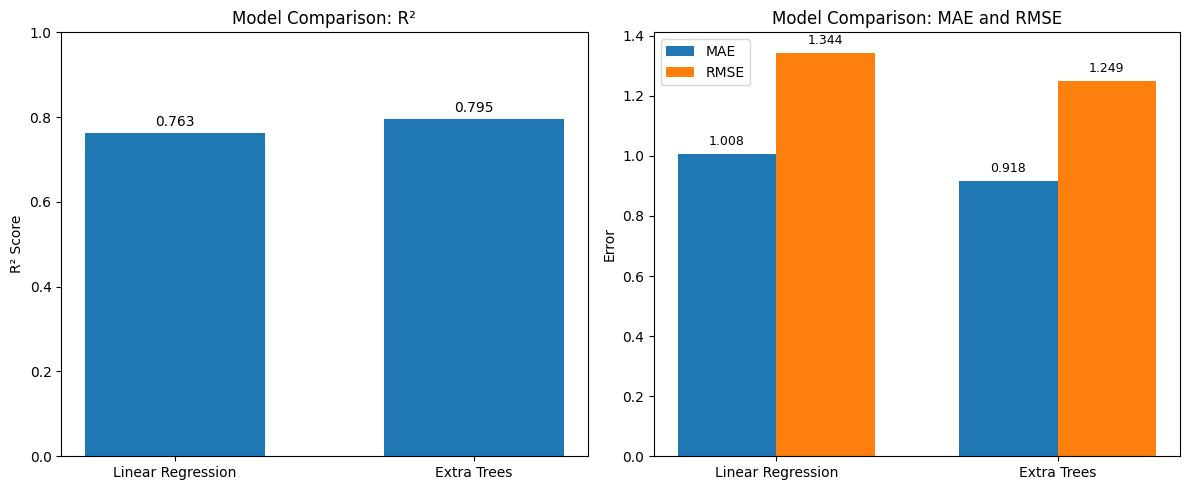

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Data from your trained models
models = ['Linear Regression', 'Extra Trees']
r2_scores = [r2_lr, r2_etr]
mae_scores = [mae_lr, mae_etr]
rmse_scores = [rmse_lr, rmse_etr]

# Set up the figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# ----- Subplot 1: R² (higher is better) -----
x = np.arange(len(models))
width = 0.6
bars1 = ax1.bar(x, r2_scores, width)
ax1.set_ylabel('R² Score')
ax1.set_title('Model Comparison: R²')
ax1.set_xticks(x)
ax1.set_xticklabels(models)
ax1.set_ylim(0, 1)
# Add value labels on bars
for bar, val in zip(bars1, r2_scores):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.3f}', ha='center', va='bottom', fontsize=10)

# ----- Subplot 2: MAE & RMSE (lower is better) -----
width_group = 0.35
x2 = np.arange(len(models))
bars_mae = ax2.bar(x2 - width_group/2, mae_scores, width_group,
                   label='MAE')
bars_rmse = ax2.bar(x2 + width_group/2, rmse_scores, width_group,
                    label='RMSE')

ax2.set_ylabel('Error')
ax2.set_title('Model Comparison: MAE and RMSE')
ax2.set_xticks(x2)
ax2.set_xticklabels(models)
ax2.legend()

# Add value labels
for bar, val in zip(bars_mae, mae_scores):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{val:.3f}', ha='center', va='bottom', fontsize=9)
for bar, val in zip(bars_rmse, rmse_scores):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{val:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()